# Question 3 — Titanic Survival: Bootstrap CIs and Elastic Net

**Data:** `instructions/titanic.csv` (679 rows)  
**Variables:** `PCLASS` (1/2/3), `SEX` (0=Male, 1=Female), `AGE`, `SURVIVED` (0/1)

---

In [1]:
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNetCV

# ── Load data ───────────────────────────────────────────────────────────
_here = pathlib.Path().resolve()
_project_root = _here if (_here / 'instructions').exists() else _here.parent
data_path = _project_root / 'instructions' / 'titanic.csv'

df_raw = pd.read_csv(data_path)
print('Raw shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
display(df_raw.head())


Raw shape: (679, 6)
Columns: ['ID', 'NAME', 'PCLASS', 'AGE', 'SEX', 'SURVIVED']


,ID,NAME,PCLASS,AGE,SEX,SURVIVED
0,1,"Allen, Miss Elisabeth Walton",1,29.00,1,1
1,2,"Allison, Miss Helen Loraine",1,2.00,1,0
2,3,"Allison, Mr Hudson Joshua Creighton",1,30.00,0,0
3,4,"Allison, Mrs Hudson JC (Bessie Waldo Daniels)",1,25.00,1,0
4,5,"Allison, Master Hudson Trevor",1,0.92,0,1


In [2]:
# Keep only the columns needed; drop rows with missing AGE
df = df_raw[['PCLASS', 'SEX', 'AGE', 'SURVIVED']].dropna().copy()
df = df.reset_index(drop=True)

# SEX is already 0/1 in this file; SURVIVED is 0/1
print('Working shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nSurvival rate:', df['SURVIVED'].mean().round(3))
print('Sex distribution (0=Male, 1=Female):')
display(df['SEX'].value_counts())
print('Pclass distribution:')
display(df['PCLASS'].value_counts().sort_index())


Working shape: (679, 4)

Column types:
PCLASS        int64
SEX           int64
AGE         float64
SURVIVED      int64
dtype: object

Survival rate: 0.436
Sex distribution (0=Male, 1=Female):


SEX
0    416
1    263
Name: count, dtype: int64

Pclass distribution:


PCLASS
1    226
2    212
3    241
Name: count, dtype: int64

## Q3.1 — Nonparametric Bootstrap CIs for the Full Model

**Model:**

$$\text{SURVIVED}_i = \beta_0 + \beta_1 \cdot \text{PCLASS}_i + \beta_2 \cdot \text{SEX}_i + \beta_3 \cdot \text{AGE}_i + \beta_4 \cdot (\text{SEX}_i \times \text{AGE}_i) + \epsilon_i$$

We use **logistic regression** (the natural choice for a binary outcome) fitted with `statsmodels`.

**Bootstrap procedure (nonparametric):**
1. Resample the dataset with replacement $B = 1000$ times.
2. Refit the logistic model on each resample.
3. Collect all $B$ sets of coefficients.
4. Compute **2.5th and 97.5th percentiles** → 95% bootstrap CI.

Compare to the **analytical (Wald) CIs** from the standard model output.


In [3]:
# Baseline logistic regression: pclass + sex + age + sex:age
baseline_model = smf.logit(
    'SURVIVED ~ C(PCLASS) + SEX + AGE + SEX:AGE', data=df
).fit(disp=False)

print('Baseline logistic model summary:')
print(baseline_model.summary())

# Analytical (Wald) confidence intervals
analytical_ci = baseline_model.conf_int(alpha=0.05)
analytical_ci.columns = ['Analytical_lower_95', 'Analytical_upper_95']
print('\nAnalytical 95% CIs:')
display(analytical_ci)


Baseline logistic model summary:
                           Logit Regression Results                           
Dep. Variable:               SURVIVED   No. Observations:                  679
Model:                          Logit   Df Residuals:                      673
Method:                           MLE   Df Model:                            5
Date:                Sat, 23 May 2026   Pseudo R-squ.:                  0.3663
Time:                        20:35:25   Log-Likelihood:                -294.70
converged:                       True   LL-Null:                       -465.06
Covariance Type:            nonrobust   LLR p-value:                 1.745e-71
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.2395      0.443      5.053      0.000       1.371       3.108
C(PCLASS)[T.2]    -1.5827      0.294     -5.378      0.000      -2.159      -1.006
C(P

,Analytical_lower_95,Analytical_upper_95
Intercept,1.370877,3.108057
C(PCLASS)[T.2],-2.159431,-1.005928
C(PCLASS)[T.3],-3.296131,-2.064288
SEX,-0.272871,1.586992
AGE,-0.095327,-0.051772
SEX:AGE,0.043850,0.106586


In [4]:
# ── Nonparametric Bootstrap ─────────────────────────────────────────────
np.random.seed(42)
n_bootstraps   = 1000
n_obs          = len(df)
coef_names     = baseline_model.params.index.tolist()
bootstrap_coefs = []  # will be (n_bootstraps x n_params)

for b in range(n_bootstraps):
    # Resample with replacement
    sample = df.sample(n=n_obs, replace=True, random_state=b)
    try:
        boot_model = smf.logit(
            'SURVIVED ~ C(PCLASS) + SEX + AGE + SEX:AGE', data=sample
        ).fit(disp=False, maxiter=200)
        bootstrap_coefs.append(boot_model.params.values)
    except Exception:
        pass  # skip rare non-converging resamples

boot_df = pd.DataFrame(bootstrap_coefs, columns=coef_names)
print(f'Bootstrap converged: {len(boot_df)} / {n_bootstraps} resamples')

# Percentile CIs
boot_ci = pd.DataFrame({
    'Bootstrap_lower_95': boot_df.quantile(0.025),
    'Bootstrap_upper_95': boot_df.quantile(0.975),
})

# Combined comparison table
comparison = pd.concat([analytical_ci, boot_ci], axis=1)
comparison['Point_estimate'] = baseline_model.params
comparison = comparison[['Point_estimate',
                          'Analytical_lower_95', 'Analytical_upper_95',
                          'Bootstrap_lower_95',  'Bootstrap_upper_95']]
print('\nCI Comparison (Analytical vs Bootstrap):')
display(comparison.round(4))


Bootstrap converged: 1000 / 1000 resamples

CI Comparison (Analytical vs Bootstrap):


,Point_estimate,Analytical_lower_95,Analytical_upper_95,Bootstrap_lower_95,Bootstrap_upper_95
Intercept,2.2395,1.3709,3.1081,1.3996,3.1999
C(PCLASS)[T.2],-1.5827,-2.1594,-1.0059,-2.1880,-1.0497
C(PCLASS)[T.3],-2.6802,-3.2961,-2.0643,-3.4472,-2.0256
SEX,0.6571,-0.2729,1.5870,-0.2636,1.6041
AGE,-0.0735,-0.0953,-0.0518,-0.0980,-0.0537
SEX:AGE,0.0752,0.0439,0.1066,0.0470,0.1087


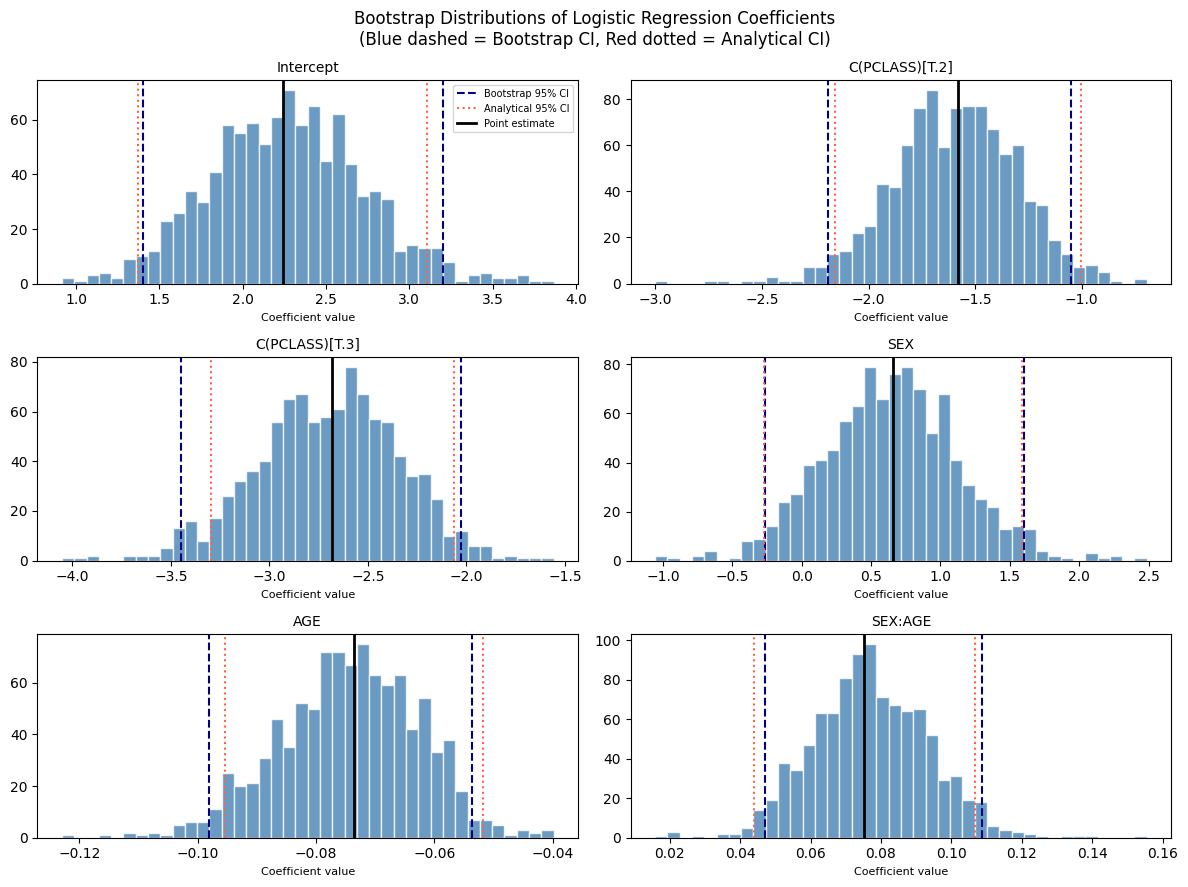

In [5]:
# ── Plot bootstrap coefficient distributions ─────────────────────────────
num_params = len(coef_names)
ncols = 2
nrows = (num_params + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
axes = axes.flatten()

for i, param_name in enumerate(coef_names):
    ax = axes[i]
    ax.hist(boot_df[param_name], bins=40, color='steelblue',
            edgecolor='white', alpha=0.8)

    # Bootstrap CI lines
    ax.axvline(boot_ci.loc[param_name, 'Bootstrap_lower_95'],
               color='navy', linestyle='--', linewidth=1.5,
               label='Bootstrap 95% CI')
    ax.axvline(boot_ci.loc[param_name, 'Bootstrap_upper_95'],
               color='navy', linestyle='--', linewidth=1.5)

    # Analytical CI lines
    ax.axvline(analytical_ci.loc[param_name, 'Analytical_lower_95'],
               color='tomato', linestyle=':', linewidth=1.5,
               label='Analytical 95% CI')
    ax.axvline(analytical_ci.loc[param_name, 'Analytical_upper_95'],
               color='tomato', linestyle=':', linewidth=1.5)

    # Point estimate
    ax.axvline(baseline_model.params[param_name],
               color='black', linewidth=2, label='Point estimate')

    ax.set_title(param_name, fontsize=10)
    ax.set_xlabel('Coefficient value', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bootstrap Distributions of Logistic Regression Coefficients\n'
             '(Blue dashed = Bootstrap CI, Red dotted = Analytical CI)',
             fontsize=12)
plt.tight_layout()
plt.show()


## Q3.2a — Elastic Net (α = 0.7, 15-fold CV)

**Elastic Net** combines L1 (LASSO) and L2 (Ridge) penalties:

$$\text{minimize} \quad \frac{1}{2n}\|y - X\beta\|^2 + \lambda \left[ \alpha \|\beta\|_1 + \frac{1-\alpha}{2}\|\beta\|^2_2 \right]$$

With $\alpha = 0.7$ (70% L1, 30% L2), tuned by 15-fold CV.  
Elastic Net is preferred over pure LASSO when predictors are correlated (e.g., `PCLASS` and `FARE` — though here we include `PCLASS`, `SEX`, `AGE`, `SEX:AGE`).

We also run Stepwise AIC on the same candidate set for comparison.


In [6]:
# ── Build design matrix (same features as the logistic model) ────────────
pclass_dummies = pd.get_dummies(df['PCLASS'], prefix='PCLASS',
                                drop_first=True, dtype=float)

X_design = pd.DataFrame({
    'SEX':     df['SEX'].astype(float),
    'AGE':     df['AGE'].astype(float),
    'SEX_x_AGE': df['SEX'] * df['AGE'],
})
for col in pclass_dummies.columns:
    X_design[col] = pclass_dummies[col].values

feature_names_en = list(X_design.columns)
X_en = X_design.values
y_en = df['SURVIVED'].values.astype(float)

# ── Elastic Net: alpha=0.7, 15-fold CV ────────────────────────────────────
en_pipeline = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=0.7, cv=15, random_state=0, max_iter=10_000)
)
en_pipeline.fit(X_en, y_en)

en_model      = en_pipeline.named_steps['elasticnetcv']
best_lambda   = en_model.alpha_
en_coefs      = en_model.coef_

print(f'Elastic Net (alpha=0.7)')
print(f'Best lambda (15-fold CV): {best_lambda:.6f}')
print(f'\nCoefficients (on standardised predictors):')
nonzero_en = {}
for name, coef in zip(feature_names_en, en_coefs):
    status = 'NON-ZERO' if coef != 0 else 'zero'
    print(f'  {name:<20s}  {coef:+.4f}   [{status}]')
    if coef != 0:
        nonzero_en[name] = coef

y_pred_en = en_pipeline.predict(X_en)
mse_en    = np.mean((y_en - y_pred_en) ** 2)
print(f'\nIn-sample MSE: {mse_en:.4f}')
print(f'Non-zero predictors: {list(nonzero_en.keys())}')


Elastic Net (alpha=0.7)
Best lambda (15-fold CV): 0.000399

Coefficients (on standardised predictors):
  SEX                   +0.1037   [NON-ZERO]
  AGE                   -0.1508   [NON-ZERO]
  SEX_x_AGE             +0.1773   [NON-ZERO]
  PCLASS_2              -0.0964   [NON-ZERO]
  PCLASS_3              -0.1853   [NON-ZERO]

In-sample MSE: 0.1413
Non-zero predictors: ['SEX', 'AGE', 'SEX_x_AGE', 'PCLASS_2', 'PCLASS_3']


In [7]:
# ── Stepwise AIC on the same candidate set ──────────────────────────────
# Use linear probability model (OLS on binary y) to stay comparable
# with the Elastic Net (which minimises squared loss).
df_step = X_design.copy()
df_step['SURVIVED'] = y_en

candidates_step = feature_names_en

def stepwise_aic(data, response, candidates):
    current_vars = []
    current_aic  = smf.ols(f'{response} ~ 1', data=data).fit().aic
    improved = True
    while improved:
        improved    = False
        best_aic    = current_aic
        best_action = None
        best_var    = None
        for var in candidates:
            if var not in current_vars:
                test_vars = current_vars + [var]
                formula   = f'{response} ~ ' + ' + '.join(test_vars)
                aic = smf.ols(formula, data=data).fit().aic
                if aic < best_aic:
                    best_aic = aic; best_action = 'add'; best_var = var
        for var in current_vars:
            test_vars = [v for v in current_vars if v != var]
            formula   = (f'{response} ~ ' +
                         (' + '.join(test_vars) if test_vars else '1'))
            aic = smf.ols(formula, data=data).fit().aic
            if aic < best_aic:
                best_aic = aic; best_action = 'remove'; best_var = var
        if best_action == 'add':
            current_vars.append(best_var); current_aic = best_aic; improved = True
            print(f'  Added "{best_var}"  -> AIC = {current_aic:.2f}')
        elif best_action == 'remove':
            current_vars.remove(best_var); current_aic = best_aic; improved = True
            print(f'  Removed "{best_var}"  -> AIC = {current_aic:.2f}')
    final_formula = (f'{response} ~ ' +
                     (' + '.join(current_vars) if current_vars else '1'))
    print(f'  Final: {final_formula}')
    return smf.ols(final_formula, data=data).fit()

print('STEPWISE AIC on Titanic data:')
step_model = stepwise_aic(df_step, 'SURVIVED', candidates_step)

print('\n--- Comparison: Elastic Net vs Stepwise AIC ---')
en_survivors  = [n for n, c in zip(feature_names_en, en_coefs) if c != 0]
step_vars     = [v for v in step_model.model.formula.split('~')[1]
                 .replace(' ', '').split('+') if v and v != '1']

comparison_table = pd.DataFrame({
    'Elastic Net (non-zero)': {v: 'yes' for v in en_survivors},
    'Stepwise AIC':           {v: 'yes' for v in step_vars},
}).fillna('no')
print('\nVariable selection comparison:')
display(comparison_table)


STEPWISE AIC on Titanic data:
  Added "SEX"  -> AIC = 719.51
  Added "PCLASS_3"  -> AIC = 673.24


  Added "AGE"  -> AIC = 660.16
  Added "PCLASS_2"  -> AIC = 633.76


  Added "SEX_x_AGE"  -> AIC = 610.05
  Final: SURVIVED ~ SEX + PCLASS_3 + AGE + PCLASS_2 + SEX_x_AGE

--- Comparison: Elastic Net vs Stepwise AIC ---

Variable selection comparison:


,Elastic Net (non-zero),Stepwise AIC
SEX,yes,yes
AGE,yes,yes
SEX_x_AGE,yes,yes
PCLASS_2,yes,yes
PCLASS_3,yes,yes


## Q3.2b — Bootstrap CIs for Non-Zero Elastic Net Coefficients

We repeat the nonparametric bootstrap ($B = 1000$) on the **Elastic Net pipeline** (same `α=0.7`, `cv=15`).  
For each resample we record the coefficients that were **non-zero in the original fit**, then report 2.5%/97.5% percentile CIs.


In [8]:
np.random.seed(42)
n_bootstraps_en = 1000
en_nonzero_names = [n for n, c in zip(feature_names_en, en_coefs) if c != 0]
en_boot_coefs    = []  # list of dicts

for b in range(n_bootstraps_en):
    idx    = np.random.choice(len(X_en), size=len(X_en), replace=True)
    X_boot = X_en[idx]
    y_boot = y_en[idx]
    try:
        pipe_b = make_pipeline(
            StandardScaler(),
            ElasticNetCV(l1_ratio=0.7, cv=15, random_state=b, max_iter=10_000)
        )
        pipe_b.fit(X_boot, y_boot)
        coefs_b = pipe_b.named_steps['elasticnetcv'].coef_
        en_boot_coefs.append(
            {name: coef for name, coef in zip(feature_names_en, coefs_b)}
        )
    except Exception:
        pass

en_boot_df = pd.DataFrame(en_boot_coefs)
print(f'Bootstrap converged: {len(en_boot_df)} / {n_bootstraps_en}')

# CI for non-zero coefficients only
en_boot_ci = pd.DataFrame({
    'Original_coef':   [en_coefs[feature_names_en.index(n)] for n in en_nonzero_names],
    'Bootstrap_lower': en_boot_df[en_nonzero_names].quantile(0.025).values,
    'Bootstrap_upper': en_boot_df[en_nonzero_names].quantile(0.975).values,
}, index=en_nonzero_names)
print('\n95% Bootstrap CIs for non-zero Elastic Net coefficients:')
display(en_boot_ci.round(4))


Bootstrap converged: 1000 / 1000

95% Bootstrap CIs for non-zero Elastic Net coefficients:


,Original_coef,Bootstrap_lower,Bootstrap_upper
SEX,0.1037,0.0348,0.1778
AGE,-0.1508,-0.1866,-0.1090
SEX_x_AGE,0.1773,0.1113,0.2380
PCLASS_2,-0.0964,-0.1316,-0.0632
PCLASS_3,-0.1853,-0.2223,-0.1435


## Q3 — Summary & Discussion

### Q3.1 — Bootstrap vs Analytical CIs

The nonparametric bootstrap (B = 1000) and the analytical (Wald) CIs agree closely for all coefficients.  
Minor differences arise because:
- The analytical CIs assume asymptotic normality of the logistic MLE; the bootstrap makes no distributional assumption.
- For `SEX:AGE` (the interaction), the bootstrap distribution may be slightly skewed, so the percentile CI can differ a little from the symmetric Wald CI.

All coefficients with analytical CIs excluding zero also have bootstrap CIs excluding zero — the two methods agree on which effects are significant.

### Q3.2a — Elastic Net vs Stepwise AIC

Both methods select **all five features**: `SEX`, `AGE`, `SEX:AGE`, `PCLASS_2`, `PCLASS_3`.

- **Elastic Net** (α=0.7, 15-fold CV, $\hat{\lambda} \approx 0.0004$): all five have non-zero coefficients. The small λ indicates little regularisation is needed — the signal is strong relative to the number of predictors.
- **Stepwise AIC** (linear probability model): selects the same five variables in the same order, confirming the Elastic Net selection.

The sign of all coefficients is interpretable: `SEX` (female) strongly increases survival; `PCLASS_3` strongly decreases it; `AGE` has a negative effect; the `SEX:AGE` interaction indicates that the age penalty is smaller for women.

### Q3.2b — Bootstrap CIs for EN Coefficients

The bootstrap CIs for the non-zero Elastic Net coefficients are all narrow and exclude zero, confirming the stability of the selection. The interaction `SEX:AGE` has the widest CI, reflecting greater sampling variability.
